# Using Machine Learning to Predict High-Elo League of Legends Match Outcomes

---



# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ `X` ] YES - make available
* [  ] NO - keep private

# NAMES:

- Yunfan Long
- Shang Zhou
- Yuxi Liu
- Nathan Truong
- Nithilan Muruganandham

# Abstract

In this project, we developed a predictive model for the outcomes of League of Legends matches. We analyzed 20 distinct features for each of the two competing teams. Through the examination of approximately 10,000 game datasets, we evaluated the influence of these features on match outcomes. To achieve this, we employed six different machine learning algorithms: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Extreme Gradient Boosting (XGBoost), and Support Vector Machine (SVM). The objective was to enhance the accuracy of predictions.

# Research Question

How accurately can the model predict the outcome of League of Legends ARAM matches by analyzing 20 features for each of the two teams among the TOP 300 ranked North American players?
<!-- investigate whether the same statistics in the middle or late stage of the game have a greater/smaller effect on the final result. -->

## Background and Prior Work

In this project, we choose League of Legends (LoL), a multiplayer online battle arena game. Players control unique characters called "champions" with specific roles and abilities. In the ARAM mode, short for "All Random, All Mid," two teams of five players, including the red team and blue team, each compete in a single lane to destroy the enemy's Nexus, a crucial structure located within each team's base; its destruction leads to the victory of the opposing team. Game performance metrics, such as the number of kills, deaths, gold earned, and experience gained, are essential indicators for the game's progression and outcome. These metrics are collected throughout the game as the dataset to build the predictive model.

Taking the Blue Team as an example, below are the detailed descriptions for each feature that we decided to enclude in out dataset:
*   `blueWins`: Indicates if the Blue Team won (1 for win, 0 for loss).
*   `blueWardsPlaced`: The total wards placed by the Blue Team to provide vision.
*   `blueWardsDestroyed`: The total wards destroyed by the Blue Team, removing enemy vision.
*   `blueFirstBlood`: Whether the Blue Team secured the first kill of the game, which grants extra gold.
*   `blueKills`: The total kills made by the Blue Team.
*   `blueDeaths`: The total times members of the Blue Team were killed.
*   `blueAssists`: The total assists made by the Blue Team, where they helped in killing an enemy.
*   `blueEliteMonsters`: The total elite monsters (dragons and heralds) killed by the Blue Team.
*   `blueDragons`: The number of dragons killed by the Blue Team. Dragons are significant monsters in the game.
*   `blueHeralds`: The number of heralds killed by the Blue Team. Heralds are smaller monsters than dragons.
*   `blueTowersDestroyed`: The total towers destroyed by the Blue Team, weakening the enemy's defense.
*   `blueTotalGold`: The total gold earned by the Blue Team, indicating their economic strength.
*   `blueAvgLevel`: The average level of the Blue Team, showing their progress in the game.
*   `blueTotalExperience`: The total experience gained by the Blue Team.
*   `blueTotalMinionsKilled`: The total minions killed by the Blue Team for gold and experience.
*   `blueTotalJungleMinionsKilled`: The total jungle minions killed by the Blue Team. Jungle minions provide extra resources.
*   `blueGoldDiff`: The gold difference between the Blue and Red Teams. A positive number indicates the Blue Team has more gold.
*   `blueExperienceDiff`: The experience difference between the Blue and Red Teams. A positive number indicates the Blue Team has more experience.
*   `blueCSPerMin`: The number of minions killed per minute by the Blue Team.
*   `blueGoldPerMin`: The amount of gold earned per minute by the Blue Team.

In previous work, data scientists have utilized machine learning models to predict match outcomes based on various in-game metrics. For example, a project on Kaggle titled “LoL - how to win” used data in the first 10 minutes to predict match results. The dataset includes approximately 10,000 ranked matches from Diamond 1 to Master tiers. The author uses feature engineering and model selection to improve prediction accuracy.

This work offers important insight for our project. Yet, we can approach this question more comprehensively: we investigate the effectiveness of predicting victories using the same game metrics, but from a dataset of web-scraped February 2024 Challenger Rank matches that includes the full game duration, rather than just the first 10 minutes. The predictive model can have a high accuracy level at ~99%.

<!-- the middle-game and late-game metrics to see whether there's a statistically significant difference in terms of the difference of their corresponding predictive power. The novelty of our approach come from the fact that, unlike all relevant notebooks on Kaggle, we would no longer be limited to just this dataset and will be able to look at broader time intervals. -->

References:

1. <a name="cite_note-1"></a> [^](#cite_ref-1) League of Legends Diamond Ranked Games (10 min). https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/data
2. <a name="cite_note-2"></a> [^](#cite_ref-2) “LoL - how to win.” Kaggle. https://www.kaggle.com/code/xiyuewang/lol-how-to-win
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Riot API https://developer.riotgames.com/apis

# Hypothesis


In League of Legends, many factors can influence which team wins, but the difference in gold between the teams is the most critical factor. Our analysis of 20 features shows that most features are correlated to the game's outcome. To be more specific, the most impactful features are “GoldDiff”, “TowersDestroyed”, “Dragons”, and others. However, there are some features with less importance because they are duplicates. For example, "blueEliteMonsters" is the sum of `blueDragons` and `blueHeralds`, so we only need to include `blueDragons` and `blueHeralds` in the analysis. We group all the data into three main categories: pros (positive indicators), cons (negative indicators), and reps (repeated indicators).

Taking the Blue Team as an example,  
*   Pros are: `blueWins`, `blueWardsPlaced`, `blueWardsDestroyed`, `blueTowersDestroyed`, "blueFirstBlood", "blueKills", "blueAssists", `blueDragons`, `blueHeralds`, `blueTotalGold`, `blueAvgLevel`, `blueTotalMinionsKilled`, `blueTotalJungleMinionsKilled`, `blueCSPerMin`, `blueGoldDiff`, `blueExperienceDiff`;
*   Cons are: `blueDeaths`;
*   Reps are: `blueEliteMonsters`, `blueTotalExperience`, `blueGoldPerMin`.

Then we use data to train six machine learning models. Following this, the model demonstrating the highest level of accuracy is selected.


# Data

## Data overview

<!-- For each dataset include the following information
- Dataset #1
  - Dataset Name: League of Legends Diamond Ranked Games (10 min)
  - Link to the dataset: https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/data
  - Number of observations: 10,000
  - Number of variables: 40 -->

<!-- - Dataset #2 (if you have more than one!)
  - Dataset Name: League of Legends Diamond Games (First 15 Minutes)
  - Link to the dataset: https://www.kaggle.com/datasets/benfattori/league-of-legends-diamond-games-first-15-minutes/data
  - Number of observations:
  - Number of variables:
- etc -->
<!-- The League of Legends Diamond Ranked Games (10 min) Dataset is a comprehensive collection of game metrics from high ELO ranked matches, capturing the first 10 minutes of gameplay. Key variables include unique game identifiers, the outcome of the match (blueWins), and various performance metrics for both the blue and red teams, such as kills, deaths, assists, gold earned, and experience gained. These metrics can serve as proxies for team performance, strategy effectiveness, and overall game dynamics. Stored in CSV format, the dataset comprises about 10,000 observations, each representing a single game -->

<!-- This text in this chapter were entirely generated by GPT-4 from the prompt "The dataset we plan to use is League of Legends Diamond Ranked Games (10 min) Dataset from Kaggle.
What variables would you have?
The dataset contains the following variables for each game, with a total of 40 columns including both teams' stats and the game outcome:
- gameId: Unique identifier for each game.
- blueWins: The target variable indicating if the blue team won (1) or not (0).
- blueWardsPlaced: Number of warding totems blue team placed.
- blueWardsDestroyed: Number of enemy warding totems blue team destroyed.
- blueFirstBlood: Indicates whether the blue team got the first kill (1) or not (0).
- blueKills: Number of kills by the blue team.
- blueDeaths: Number of times blue team members were killed.
- blueAssists: Number of assists by the blue team.
- blueEliteMonsters: Number of elite monsters the blue team killed.
- blueDragons: Number of dragons blue team killed.
- blueHeralds: Number of heralds blue team killed.
- blueTowersDestroyed: Number of enemy towers blue team destroyed.
- blueTotalGold: Total gold earned by the blue team.
- blueAvgLevel: Average level of blue team's champions.
- blueTotalExperience: Total experience earned by the blue team.
- blueTotalMinionsKilled: Total number of minions killed by the blue team.
- blueTotalJungleMinionsKilled: Total number of jungle minions killed by the blue team.
- blueGoldDiff: Gold difference in favor of the blue team compared to the red team.
- blueExperienceDiff: Experience difference in favor of the blue team compared to the red team.
- blueCSPerMin: Blue team's minion kills per minute.
- blueGoldPerMin: Blue team's gold earned per minute.
The corresponding variables for the red team mirror those of the blue team, with the prefix "red" replacing "blue," covering redWardsPlaced through redGoldPerMin.

### How would they be stored?
The dataset is stored in a CSV (Comma Separated Values) format, which is a common, easy-to-use file format for storing tabular data.

### How many observations would you have?
The dataset consists of approximately 10,000 observations, where each observation corresponds to a unique ranked game.

###  What/who would the observations be?
Each observation represents the first 10 minutes of a single high ELO (Diamond I to Master tier) ranked game in League of Legends, capturing various metrics related to both the blue and red teams' performance.

###  Over what time period?
The dataset was published on Kaggle in 2020.


write sentences describing the dataset here. Include a short description of the important variables in the dataset; what the metrics and datatypes are, what concepts they may be proxies for. Include information about how you would need to wrangle/clean/preprocess the dataset -->

This dataset is created using Riot Games API call, focusing on top-level play to understand advanced strategies and performance indicators.

Title: Dataset of League of Legends Matches by Top 300 NA Players from Challenger Ranked Gameplay
Source: Riot Games API for League of Legends.
Data Collection Process:
- We start by collecting the IDs of the Top 300 Challenger League players through the Ladder Ranking API.
- Next, we use these IDs to get the players' PUUIDs, which are unique account identifiers across Riot's games.
- We then gather data on the most recent 65 matches for each player, making a total of 11,013 matches. We narrow this down to the latest 10,000 matches only covering the past 21 days of play.

Data Points Included: Match IDs, metrics like kills, deaths, assists, gold earned, etc., outcomes of wins or losses, and other detailed statistics from each match.

Final Dataset: Our dataset contains 10,000 matches from the Challenger Leagues. The "League of Legends Top 300 NA Players Challenger Ranked Games Dataset" is a detailed collection of game statistics from the top 300 ranked LOL players in February 2024, focusing on ARAM matches. It includes key information such as unique game IDs, the match outcome (blueWins), and various performance metrics for both teams, like kills, deaths, assists, gold, and experience. The data, stored in a CSV format, includes about 10,000 records, each representing one game.

By examining this dataset, we aim to predict the winner based on various metrics, which could help players improve t.
ir gameplay.

<!-- This text in this chapter were entirely generated by GPT-4 (Continue on
the above) from the prompt "- Dataset #1
  - Dataset Name: League of Legends Diamond Ranked Games (10 min)
  - Link to the dataset: https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/data
  - Number of observations: 10,000
  - Number of variables: 40


Dataset #2 (if you have more than one!)
  - Dataset Name:
  - Link to the dataset:
  - Number of observations:
  - Number of variables:
- etc

draft a dataset description for the webscraping and add a few sentences about how you plan to combine thesemissing values.



<!-- This text in this chapter were entirely generated by GPT-4 (Continue on
the above) from the prompt "Include more information about how you would need to wrangle/clean/preprocess the dataset, feel free to brainstorm." -->


### Dataset #1: League of Legends Matches by Top 300 NA Players from Challenger Ranked Gameplays

The following is a brief description of the dataset construction process:
We obtained the IDs of the current 300 Challenger Leagues players by calling the Ladder Ranking API, with a total of 288 successful API calls.


We obtained the players' PUUIDs using their IDs.


```python
import requests
import json
import time

api_key = "your_api_key_here"
headers = {"X-Riot-Token": api_key}
region = "your_region_here"

challenger_league_url = f"https://{region}.api.riotgames.com/lol/league/v4/challengerleagues/by-queue/RANKED_SOLO_5x5?api_key={api_key}"
response = requests.get(challenger_league_url, headers=headers)
if response.status_code == 200:
    league_data = response.json()
    print(league_data)
else:
    print("Failed to fetch challenger league data")
```

We fetched the correponding match IDs associated with players' PUUIDs.
`https://{region}.api.riotgames.com/lol/summoner/v4/summoners/by-name/%7Bsummoner_name.replace(' ', '%20')}`
```python
# Fetch match IDs using PUUIDs
puuids = ["bGeLHMMwkPjegYJiVDsVn3au3KqspDyl-hqMBPkv81dyIFSY3-1f1KGv-HPBMvgk0xRM2fGRmLpWng", ..]
start = 0
count = 60
for puuid in puuids:
    match_ids_url = f"https://{region}.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids?start={start}&count={count}"
    response = requests.get(match_ids_url, headers=headers)
    if response.status_code == 200:
        match_ids = response.json()
        print(match_ids)
    else:
        print("Failed to fetch match IDs")
```
We retrieved the most recent 65 matches for each player, resulting in a total of 11,013 different matches. We then selected the most recent 10,000 matches by comparing the start times of the games, specifically in Feb 2024.

```python
# Fetch match data for each Match ID and save to a file
matches_id = ["NA1_4932886745", ..]
limit = 10000
batch_size = 200
all_match_data = []

with open('match_data_10000.json', 'w') as file:
    json.dump([], file)

for count, match_id in enumerate(match_ids[0:limit], start=1):
    url = f"https://{region}.api.riotgames.com/lol/match/v5/matches/{match_id}"
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        match_data = response.json()
        all_match_data.append(match_data)
        print(count, f"Downloaded match data for {match_id}")
    else:
        print(f"Failed to fetch data for {match_id}, Status code: {response.status_code}")
        
    if count % batch_size == 0:
        with open('match_data_10000.json', 'r') as file:
            file_data = json.load(file)
        file_data.extend(all_match_data)
        with open('match_data_10000.json', 'w') as file:
            json.dump(file_data, file)
        all_match_data = []
        print(f"Updated file after downloading {count} matches")

    time.sleep(1.2)
```


We collected the full 10,000 matches we scraped in `match_data_10000.json`.

**Parse Data**

<!-- This code was mostly generated by GPT-4 from the prompt "write out the complete code for me to extract every single column for me, both for red and blue teams. To remind you, the columns are: blueWins	blueWardsPlaced	blueWardsDestroyed	blueFirstBlood	blueKills	blueDeaths	blueAssists	blueEliteMonsters	blueDragons	blueHeralds	blueTowersDestroyed	blueTotalGold	blueAvgLevel	blueTotalExperience	blueTotalMinionsKilled	blueTotalJungleMinionsKilled	blueGoldDiff	blueExperienceDiff	blueCSPerMin	blueGoldPerMin	redWardsPlaced	redWardsDestroyed	redFirstBlood	redKills	redDeaths	redAssists	redEliteMonsters	redDragons	redHeralds	redTowersDestroyed	redTotalGold	redAvgLevel	redTotalExperience	redTotalMinionsKilled	redTotalJungleMinionsKilled	redGoldDiff	redExperienceDiff	redCSPerMin	redGoldPerMin


You also want to make sure the info actually has the key, for example, p['dragonKills'] is not an actual key in the json, to ensure the accuracy, I will show you both the general structure and the actual information within json.

print(pd.read_json("match_data.json")["info"].loc[0].keys())
dict_keys(['endOfGameResult', 'gameCreation', 'gameDuration', 'gameEndTimestamp', 'gameId', 'gameMode', 'gameName', 'gameStartTimestamp', 'gameType', 'gameVersion', 'mapId', 'participants', 'platformId', 'queueId', 'teams', 'tournamentCode'])

print(pd.read_json("match_data.json")["info"].loc[0]['participants'][0])
{'allInPings': 0,
 'assistMePings': 1,
 'assists': 7,
 'baronKills': 0,
 'basicPings': 0,
 'bountyLevel': 4,
 'challenges': {'12AssistStreakCount': 0,
  'abilityUses': 252,
  'acesBefore15Minutes': 0,
  'alliedJungleMonsterKills': 0,
  'baronBuffGoldAdvantageOverThreshold': 1,
  'baronTakedowns': 0,
  'blastConeOppositeOpponentCount': 0,
  'bountyGold': 0,
  'buffsStolen': 0,
  'completeSupportQuestInTime': 0,
  'controlWardTimeCoverageInRiverOrEnemyHalf': 0.730790023886107,
  'controlWardsPlaced': 4,
  'damagePerMinute': 875.0464275130538,
  'damageTakenOnTeamPercentage': 0.25979634833320503,
  'dancedWithRiftHerald': 0,
  'deathsByEnemyChamps': 6,
  'dodgeSkillShotsSmallWindow': 0,
  'doubleAces': 0,
  'dragonTakedowns': 0,
  'earliestBaron': 1322.2824415999999,
  'earlyLaningPhaseGoldExpAdvantage': 0,
  'effectiveHealAndShielding': 0,
  'elderDragonKillsWithOpposingSoul': 0,
  'elderDragonMultikills': 0,
  'enemyChampionImmobilizations': 0,
  'enemyJungleMonsterKills': 0,
  'epicMonsterKillsNearEnemyJungler': 0,
  'epicMonsterKillsWithin30SecondsOfSpawn': 0,
  'epicMonsterSteals': 0,
  'epicMonsterStolenWithoutSmite': 0,
  'firstTurretKilled': 1,
  'firstTurretKilledTime': 772.1686007999999,
  'flawlessAces': 2,
  'fullTeamTakedown': 0,
  'gameLength': 1515.1021532999998,
  'getTakedownsInAllLanesEarlyJungleAsLaner': 0,
  'goldPerMinute': 431.14017416399116,
  'hadOpenNexus': 0,
  'highestChampionDamage': 1,
  'immobilizeAndKillWithAlly': 0,
  'initialBuffCount': 0,
  'initialCrabCount': 0,
  'jungleCsBefore10Minutes': 0,
  'junglerTakedownsNearDamagedEpicMonster': 0,
  'kTurretsDestroyedBeforePlatesFall': 0,
  'kda': 2.166666666666666,
  'killAfterHiddenWithAlly': 1,
  'killParticipation': 0.59090909090909,
  'killedChampTookFullTeamDamageSurvived': 0,
  'killingSprees': 1,
  'killsNearEnemyTurret': 3,
  'killsOnOtherLanesEarlyJungleAsLaner': 0,
  'killsOnRecentlyHealedByAramPack': 0,
  'killsUnderOwnTurret': 0,
  'killsWithHelpFromEpicMonster': 0,
  'knockEnemyIntoTeamAndKill': 0,
  'landSkillShotsEarlyGame': 15,
  'laneMinionsFirst10Minutes': 77,
  'laningPhaseGoldExpAdvantage': 0,
  'legendaryCount': 0,
  'legendaryItemUsed': [3152, 3100],
  'lostAnInhibitor': 0,
  'maxCsAdvantageOnLaneOpponent': 27,
  'maxKillDeficit': 3,
  'maxLevelLeadLaneOpponent': 2,
  'mejaisFullStackInTime': 0,
  'moreEnemyJungleThanOpponent': 0,
  'multiKillOneSpell': 0,
  'multiTurretRiftHeraldCount': 0,
  'multikills': 1,
  'multikillsAfterAggressiveFlash': 0,
  'outerTurretExecutesBefore10Minutes': 0,
  'outnumberedKills': 3,
  'outnumberedNexusKill': 0,
  'perfectDragonSoulsTaken': 0,
  'perfectGame': 0,
  'pickKillWithAlly': 7,
  'playedChampSelectPosition': 1,
  'poroExplosions': 0,
  'quickCleanse': 0,
  'quickFirstTurret': 0,
  'quickSoloKills': 0,
  'riftHeraldTakedowns': 0,
  'saveAllyFromDeath': 0,
  'scuttleCrabKills': 0,
  'skillshotsDodged': 12,
  'skillshotsHit': 56,
  'snowballsHit': 0,
  'soloBaronKills': 0,
  'soloKills': 3,
  'stealthWardsPlaced': 7,
  'survivedSingleDigitHpCount': 0,
  'survivedThreeImmobilizesInFight': 0,
  'takedownOnFirstTurret': 0,
  'takedowns': 13,
  'takedownsAfterGainingLevelAdvantage': 0,
  'takedownsBeforeJungleMinionSpawn': 0,
  'takedownsFirstXMinutes': 5,
  'takedownsInAlcove': 0,
  'takedownsInEnemyFountain': 0,
  'teamBaronKills': 1,
  'teamDamagePercentage': 0.29645836773735,
  'teamElderDragonKills': 0,
  'teamRiftHeraldKills': 1,
  'teleportTakedowns': 2,
  'tookLargeDamageSurvived': 0,
  'turretPlatesTaken': 3,
  'turretTakedowns': 4,
  'turretsTakenWithRiftHerald': 0,
  'twentyMinionsIn3SecondsCount': 0,
  'twoWardsOneSweeperCount': 0,
  'unseenRecalls': 0,
  'visionScoreAdvantageLaneOpponent': 0.28622198104858404,
  'visionScorePerMinute': 0.9547090284053611,
  'wardTakedowns': 0,
  'wardTakedownsBefore20M': 0,
  'wardsGuarded': 0},
 'champExperience': 13290,
 'champLevel': 15,
 'championId': 84,
 'championName': 'Akali',
 'championTransform': 0,
 'commandPings': 6,
 'consumablesPurchased': 6,
 'damageDealtToBuildings': 7008,
 'damageDealtToObjectives': 7747,
 'damageDealtToTurrets': 7008,
 'damageSelfMitigated': 11271,
 'dangerPings': 0,
 'deaths': 6,
 'detectorWardsPlaced': 4,
 'doubleKills': 1,
 'dragonKills': 0,
 'eligibleForProgression': True,
 'enemyMissingPings': 0,
 'enemyVisionPings': 3,
 'firstBloodAssist': False,
 'firstBloodKill': False,
 'firstTowerAssist': False,
 'firstTowerKill': False,
 'gameEndedInEarlySurrender': False,
 'gameEndedInSurrender': False,
 'getBackPings': 2,
 'goldEarned': 10887,
 'goldSpent': 9590,
 'holdPings': 0,
 'individualPosition': 'TOP',
 'inhibitorKills': 0,
 'inhibitorTakedowns': 0,
 'inhibitorsLost': 0,
 'item0': 3152,
 'item1': 0,
 'item2': 2421,
 'item3': 3100,
 'item4': 3020,
 'item5': 0,
 'item6': 3363,
 'itemsPurchased': 25,
 'killingSprees': 1,
 'kills': 6,
 'lane': 'JUNGLE',
 'largestCriticalStrike': 0,
 'largestKillingSpree': 4,
 'largestMultiKill': 2,
 'longestTimeSpentLiving': 317,
 'magicDamageDealt': 106644,
 'magicDamageDealtToChampions': 19876,
 'magicDamageTaken': 8055,
 'missions': {'playerScore0': 0,
  'playerScore1': 0,
  'playerScore10': 0,
  'playerScore11': 0,
  'playerScore2': 0,
  'playerScore3': 0,
  'playerScore4': 0,
  'playerScore5': 0,
  'playerScore6': 0,
  'playerScore7': 0,
  'playerScore8': 0,
  'playerScore9': 0},
 'needVisionPings': 0,
 'neutralMinionsKilled': 0,
 'nexusKills': 0,
 'nexusLost': 0,
 'nexusTakedowns': 1,
 'objectivesStolen': 0,
 'objectivesStolenAssists': 0,
 'onMyWayPings': 2,
 'participantId': 1,
 'pentaKills': 0,
 'perks': {'statPerks': {'defense': 5001, 'flex': 5008, 'offense': 5008},
  'styles': [{'description': 'primaryStyle',
    'selections': [{'perk': 8010, 'var1': 589, 'var2': 0, 'var3': 0},
     {'perk': 8009, 'var1': 750, 'var2': 0, 'var3': 0},
     {'perk': 9104, 'var1': 15, 'var2': 20, 'var3': 0},
     {'perk': 8299, 'var1': 577, 'var2': 0, 'var3': 0}],
    'style': 8000},
   {'description': 'subStyle',
    'selections': [{'perk': 8473, 'var1': 718, 'var2': 0, 'var3': 0},
     {'perk': 8451, 'var1': 199, 'var2': 0, 'var3': 0}],
    'style': 8400}]},
 'physicalDamageDealt': 14201,
 'physicalDamageDealtToChampions': 1458,
 'physicalDamageTaken': 13566,
 'placement': 0,
 'playerAugment1': 0,
 'playerAugment2': 0,
 'playerAugment3': 0,
 'playerAugment4': 0,
 'playerScore0': 0,
 'playerScore1': 0,
 'playerScore10': 0,
 'playerScore11': 0,
 'playerScore2': 0,
 'playerScore3': 0,
 'playerScore4': 0,
 'playerScore5': 0,
 'playerScore6': 0,
 'playerScore7': 0,
 'playerScore8': 0,
 'playerScore9': 0,
 'playerSubteamId': 0,
 'profileIcon': 29,
 'pushPings': 0,
 'puuid': 'EvWtIeeoKzz6EDcYB9nsgwAO7g56X66JA5zOI761SFlJub1ZZHKNwwlq3tm8GC_M6E3fPyckqe8gBg',
 'quadraKills': 0,
 'riotIdGameName': 'Castle',
 'riotIdTagline': 'jo13',
 'role': 'NONE',
 'sightWardsBoughtInGame': 0,
 'spell1Casts': 145,
 'spell2Casts': 29,
 'spell3Casts': 62,
 'spell4Casts': 16,
 'subteamPlacement': 0,
 'summoner1Casts': 5,
 'summoner1Id': 14,
 'summoner2Casts': 4,
 'summoner2Id': 12,
 'summonerId': 'j767YWv-fD4MpidwKMWcw5_NlFRv6sRBchKHErW3oWTzL0Ft1bTc1xjH_A',
 'summonerLevel': 41,
 'summonerName': '4zVXskKt4jIMDfIr',
 'teamEarlySurrendered': False,
 'teamId': 100,
 'teamPosition': 'TOP',
 'timeCCingOthers': 2,
 'timePlayed': 1515,
 'totalAllyJungleMinionsKilled': 0,
 'totalDamageDealt': 135933,
 'totalDamageDealtToChampions': 22096,
 'totalDamageShieldedOnTeammates': 0,
 'totalDamageTaken': 22032,
 'totalEnemyJungleMinionsKilled': 0,
 'totalHeal': 632,
 'totalHealsOnTeammates': 0,
 'totalMinionsKilled': 166,
 'totalTimeCCDealt': 112,
 'totalTimeSpentDead': 159,
 'totalUnitsHealed': 1,
 'tripleKills': 0,
 'trueDamageDealt': 15087,
 'trueDamageDealtToChampions': 762,
 'trueDamageTaken': 410,
 'turretKills': 0,
 'turretTakedowns': 4,
 'turretsLost': 4,
 'unrealKills': 0,
 'visionClearedPings': 0,
 'visionScore': 24,
 'visionWardsBoughtInGame': 4,
 'wardsKilled': 0,
 'wardsPlaced': 11,
 'win': True}

print(pd.read_json("match_data.json")["info"].loc[0]['teams'])
[{'bans': [{'championId': 157, 'pickTurn': 1},
   {'championId': 107, 'pickTurn': 2},
   {'championId': 432, 'pickTurn': 3},
   {'championId': 68, 'pickTurn': 4},
   {'championId': 5, 'pickTurn': 5}],
  'objectives': {'baron': {'first': True, 'kills': 1},
   'champion': {'first': False, 'kills': 22},
   'dragon': {'first': True, 'kills': 2},
   'horde': {'first': True, 'kills': 6},
   'inhibitor': {'first': True, 'kills': 1},
   'riftHerald': {'first': True, 'kills': 1},
   'tower': {'first': True, 'kills': 9}},
  'teamId': 100,
  'win': True},
 {'bans': [{'championId': 39, 'pickTurn': 6},
   {'championId': 53, 'pickTurn': 7},
   {'championId': 200, 'pickTurn': 8},
   {'championId': 901, 'pickTurn': 9},
   {'championId': 902, 'pickTurn': 10}],
  'objectives': {'baron': {'first': False, 'kills': 0},
   'champion': {'first': True, 'kills': 12},
   'dragon': {'first': False, 'kills': 1},
   'horde': {'first': False, 'kills': 0},
   'inhibitor': {'first': False, 'kills': 0},
   'riftHerald': {'first': False, 'kills': 0},
   'tower': {'first': False, 'kills': 4}},
  'teamId': 200,
  'win': False}]" Modifications are made to align the generated columns names with the dataset #1 we used to ensure the contingency of the variable name and the analysis -->

In [ ]:
import pandas as pd

def parse_match_data(info):
    teams = {100: 'blue', 200: 'red'}

    row_data = {'gameId': info['gameId']}

    team_stats = {'blue': {}, 'red': {}}
    for team in info['teams']:
        team_prefix = teams[team['teamId']]
        row_data[f'{team_prefix}Wins'] = int(team['win'])
        team_objectives = team['objectives']

        row_data[f'{team_prefix}WardsDestroyed'] = team_objectives['tower']['kills']
        row_data[f'{team_prefix}EliteMonsters'] = team_objectives['dragon']['kills'] + team_objectives['riftHerald']['kills']
        row_data[f'{team_prefix}Dragons'] = team_objectives['dragon']['kills']
        row_data[f'{team_prefix}Heralds'] = team_objectives['riftHerald']['kills']
        row_data[f'{team_prefix}TowersDestroyed'] = team_objectives['tower']['kills']

        team_stats[team_prefix] = {
            'wardsPlaced': 0, 'wardsDestroyed': 0, 'kills': 0, 'deaths': 0,
            'assists': 0, 'totalGold': 0, 'totalExperience': 0,
            'totalMinionsKilled': 0, 'totalJungleMinionsKilled': 0, 'avgLevel': 0,
        }

    for participant in info['participants']:
        team_prefix = teams[participant['teamId']]
        participant_stats = team_stats[team_prefix]
        participant_stats['wardsPlaced'] += participant['wardsPlaced']
        participant_stats['wardsDestroyed'] += participant['wardsKilled']
        participant_stats['kills'] += participant['kills']
        participant_stats['deaths'] += participant['deaths']
        participant_stats['assists'] += participant['assists']
        participant_stats['totalGold'] += participant['goldEarned']
        participant_stats['totalExperience'] += participant['champExperience']
        participant_stats['totalMinionsKilled'] += participant['totalMinionsKilled']
        participant_stats['totalJungleMinionsKilled'] += participant['neutralMinionsKilled']
        participant_stats['avgLevel'] += participant['champLevel']

    for team_prefix, stats in team_stats.items():
        player_count = 5
        row_data[f'{team_prefix}WardsPlaced'] = stats['wardsPlaced']
        row_data[f'{team_prefix}WardsDestroyed'] = stats['wardsDestroyed']
        row_data[f'{team_prefix}Kills'] = stats['kills']
        row_data[f'{team_prefix}Deaths'] = stats['deaths']
        row_data[f'{team_prefix}Assists'] = stats['assists']
        row_data[f'{team_prefix}TotalGold'] = stats['totalGold']
        row_data[f'{team_prefix}AvgLevel'] = stats['avgLevel'] / player_count
        row_data[f'{team_prefix}TotalExperience'] = stats['totalExperience']
        row_data[f'{team_prefix}TotalMinionsKilled'] = stats['totalMinionsKilled']
        row_data[f'{team_prefix}TotalJungleMinionsKilled'] = stats['totalJungleMinionsKilled']
        row_data[f'{team_prefix}CSPerMin'] = stats['totalMinionsKilled'] / (info['gameDuration'] / 60)
        row_data[f'{team_prefix}GoldPerMin'] = stats['totalGold'] / (info['gameDuration'] / 60)

    row_data['blueGoldDiff'] = team_stats['blue']['totalGold'] - team_stats['red']['totalGold']
    row_data['blueExperienceDiff'] = team_stats['blue']['totalExperience'] - team_stats['red']['totalExperience']
    row_data['redGoldDiff'] = -row_data['blueGoldDiff']
    row_data['redExperienceDiff'] = -row_data['blueExperienceDiff']

    first_blood = next((participant for participant in info['participants'] if participant.get('firstBloodKill', False)), None)
    if first_blood:
        fb_team = teams[first_blood['teamId']]
        row_data[f'{fb_team}FirstBlood'] = 1
        other_team = 'red' if fb_team == 'blue' else 'blue'
        row_data[f'{other_team}FirstBlood'] = 0

    return pd.Series(row_data)

challenger = pd.read_json('drive/MyDrive/COGS108/match_data_10000.json')['info'].apply(parse_match_data)
challenger.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9979 entries, 0 to 9978
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9979 non-null   float64
 1   blueWins                      9979 non-null   float64
 2   blueWardsDestroyed            9979 non-null   float64
 3   blueEliteMonsters             9979 non-null   float64
 4   blueDragons                   9979 non-null   float64
 5   blueHeralds                   9979 non-null   float64
 6   blueTowersDestroyed           9979 non-null   float64
 7   redWins                       9979 non-null   float64
 8   redWardsDestroyed             9979 non-null   float64
 9   redEliteMonsters              9979 non-null   float64
 10  redDragons                    9979 non-null   float64
 11  redHeralds                    9979 non-null   float64
 12  redTowersDestroyed            9979 non-null   float64
 13  blu

# Setup

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Data Cleaning

From the challenger.info() above, we observe null values in the blueFirstBlood and redFirstBlood columns. Therefore, We decided to drop all observations containing Null.

In [ ]:
challenger = challenger.dropna()

We want to reorder the columns so that:
- Metrics columns from the same team (blue or red) are grouped together
- More relevant metrics to put more relevant terms close to each other based on our understanding about the LOL game.

In [ ]:
new_columns_order = [
    'gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths',
    'blueAssists', 'blueEliteMonsters', 'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold',
    'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled',
    'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
    'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds',
    'redTowersDestroyed', 'redTotalGold', 'redAvgLevel', 'redTotalExperience', 'redTotalMinionsKilled',
    'redTotalJungleMinionsKilled', 'redGoldDiff', 'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'
]

challenger = challenger.reindex(columns=new_columns_order)

As seen in the challenger.info() above, we find that all data are of type "float". To be consistent with the data's inherent meaning, we convert all data into the type they should be. The aggregated feature involving calculating average and per-minute statistics are left in float type.

In [ ]:
exclude_columns = ['blueAvgLevel', 'blueCSPerMin', 'blueGoldPerMin',
                   'redAvgLevel', 'redCSPerMin', 'redGoldPerMin']

for column in challenger.columns:
    if column not in exclude_columns:
        challenger[column] = challenger[column].astype(int)

Visualize the first five lines of challenger dataset to ensure the processing are actually done.

In [ ]:
challenger.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4932886745,1,0,0,1,54,52,156,0,0,...,1,62797,16.6,82040,203,0,-3939,-6590,11.611058,3591.820782
1,4932884269,0,35,9,0,8,26,7,0,0,...,8,39242,10.2,35352,404,88,10011,5422,25.171340,2444.984424
2,4932881050,0,45,9,1,14,25,19,0,0,...,3,42049,12.2,48658,537,112,4372,6819,26.827644,2100.699417
3,4932877471,1,0,0,0,44,41,129,0,0,...,2,64867,16.8,85084,248,0,-3185,-6264,12.984293,3396.178010
4,4932874863,1,35,5,1,27,8,22,3,2,...,1,30429,10.2,35248,400,85,-15189,-9553,19.559902,1487.970660


# DATA ANALYSIS & RESULTS

Through visualization, we show that there is no significant difference in the mean value of each metric between the two teams.

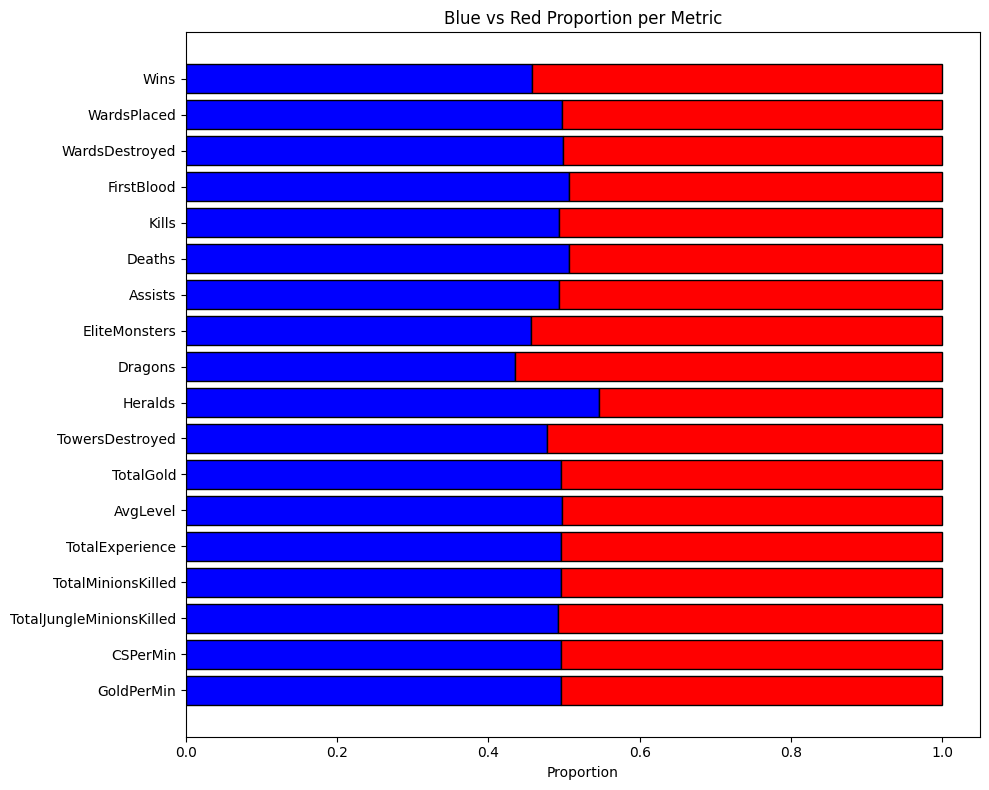

In [ ]:
blue_columns = [col for col in challenger.columns if 'blue' in col]
blue_df = challenger[blue_columns]

challenger['redWins'] = 1 - challenger['blueWins']

red_columns = [col.replace('blue', 'red') for col in blue_columns]
red_df = challenger[red_columns]

blue_series = blue_df.mean()
red_series = red_df.mean()

blue_series.index = blue_series.index.str.replace('blue', '')
red_series.index = red_series.index.str.replace('red', '')

blue_series.drop(['GoldDiff', 'ExperienceDiff'], inplace=True)
red_series.drop(['GoldDiff', 'ExperienceDiff'], inplace=True)

df = pd.concat([blue_series, red_series], axis=1)
df.columns = ['Blue', 'Red']

df['Blue Proportion'] = df['Blue'] / (df['Blue'] + df['Red'])
df['Red Proportion'] = df['Red'] / (df['Blue'] + df['Red'])

fig, ax = plt.subplots(figsize=(10, 8))

for i, (metric, row) in enumerate(df.iterrows()):
    ax.barh(y=i, width=row['Blue Proportion'], color='blue', edgecolor='black')
    ax.barh(y=i, width=row['Red Proportion'], left=row['Blue Proportion'], color='red', edgecolor='black')

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.index)
ax.set_xlabel('Proportion')
ax.set_title('Blue vs Red Proportion per Metric')

ax.invert_yaxis()

plt.tight_layout()
plt.show()

We conduct a correlation analysis below to get an idea of the relationship of each variable with the other and, most importantly, the winning outcome `blueWins`. From this chart, we see that the difference for each feature between the blue team and the red team is relatively small.


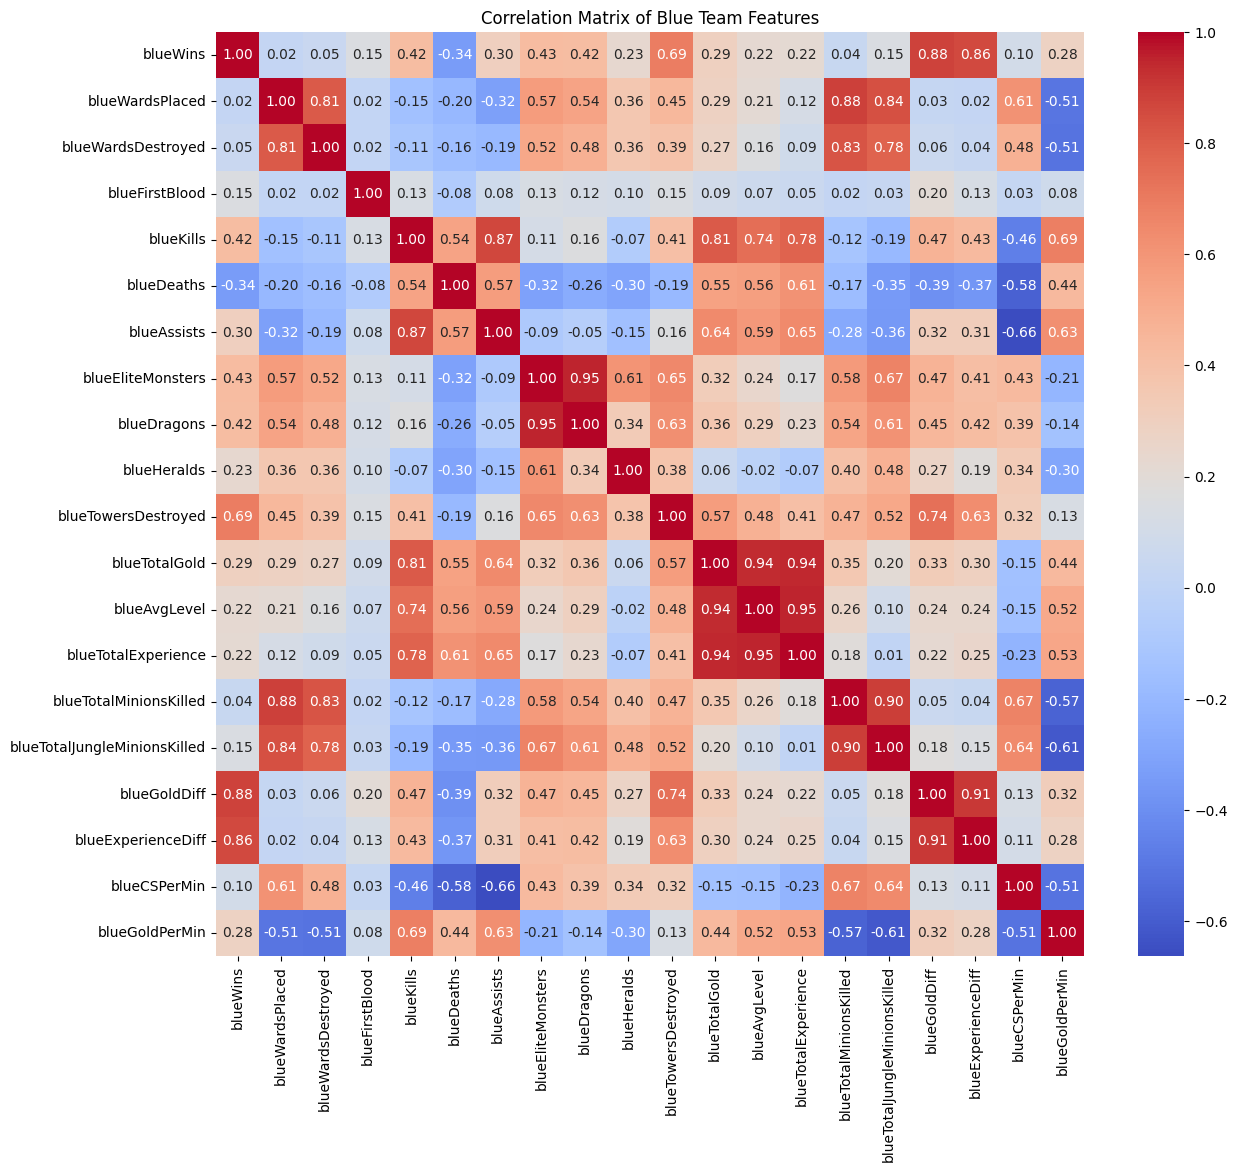

In [ ]:
corr = blue_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Blue Team Features')
plt.show()

This figure above shows the correlation matrix of the blue team’s 20 features, whose values represent the impact of the feature on the prediction results. Red cells represent positive indicators which the darker the color, the larger the value, and the greater its positive impact on the results. Blue cells represent negative indicators which the darker the color, the smaller the value, and the greater its negative impact on the results.

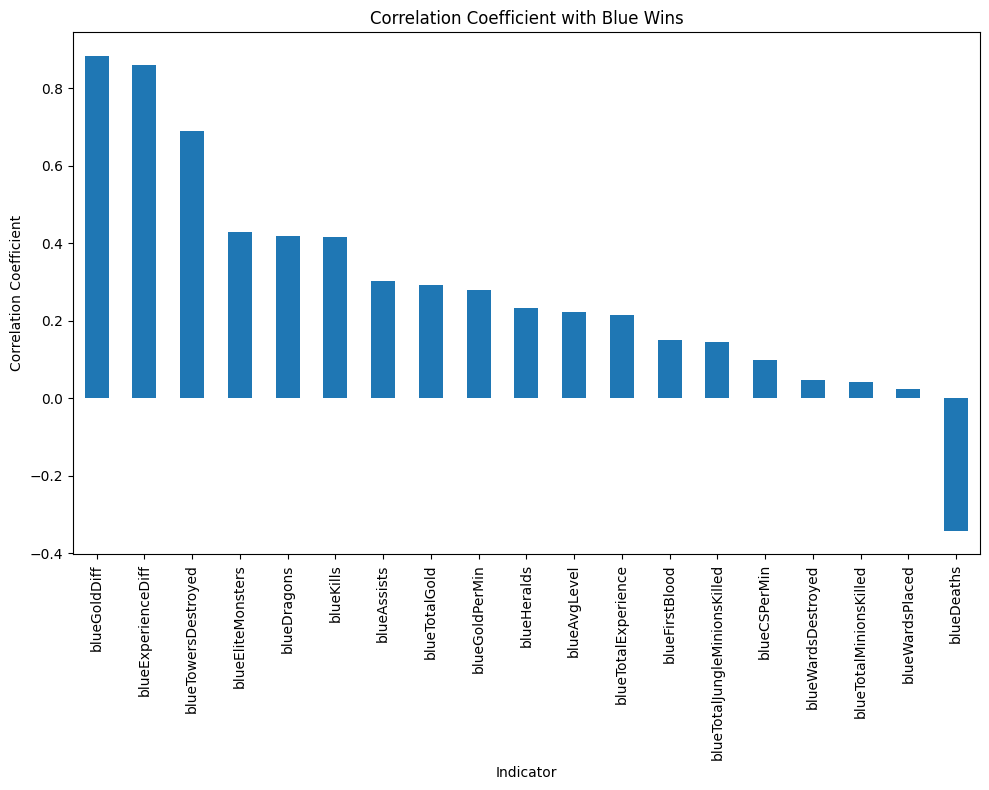

In [ ]:
correlation_coeffs = blue_df.corr()['blueWins'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlation_coeffs.drop('blueWins').plot(kind='bar')
plt.title('Correlation Coefficient with Blue Wins')
plt.xlabel('Indicator')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

The chart above was created in order to know which features will have a greater impact on the results of the game. It shows the impact of each feature on Blue Wins by looking the correlation coefficient, the higher in value means the greater on impact.

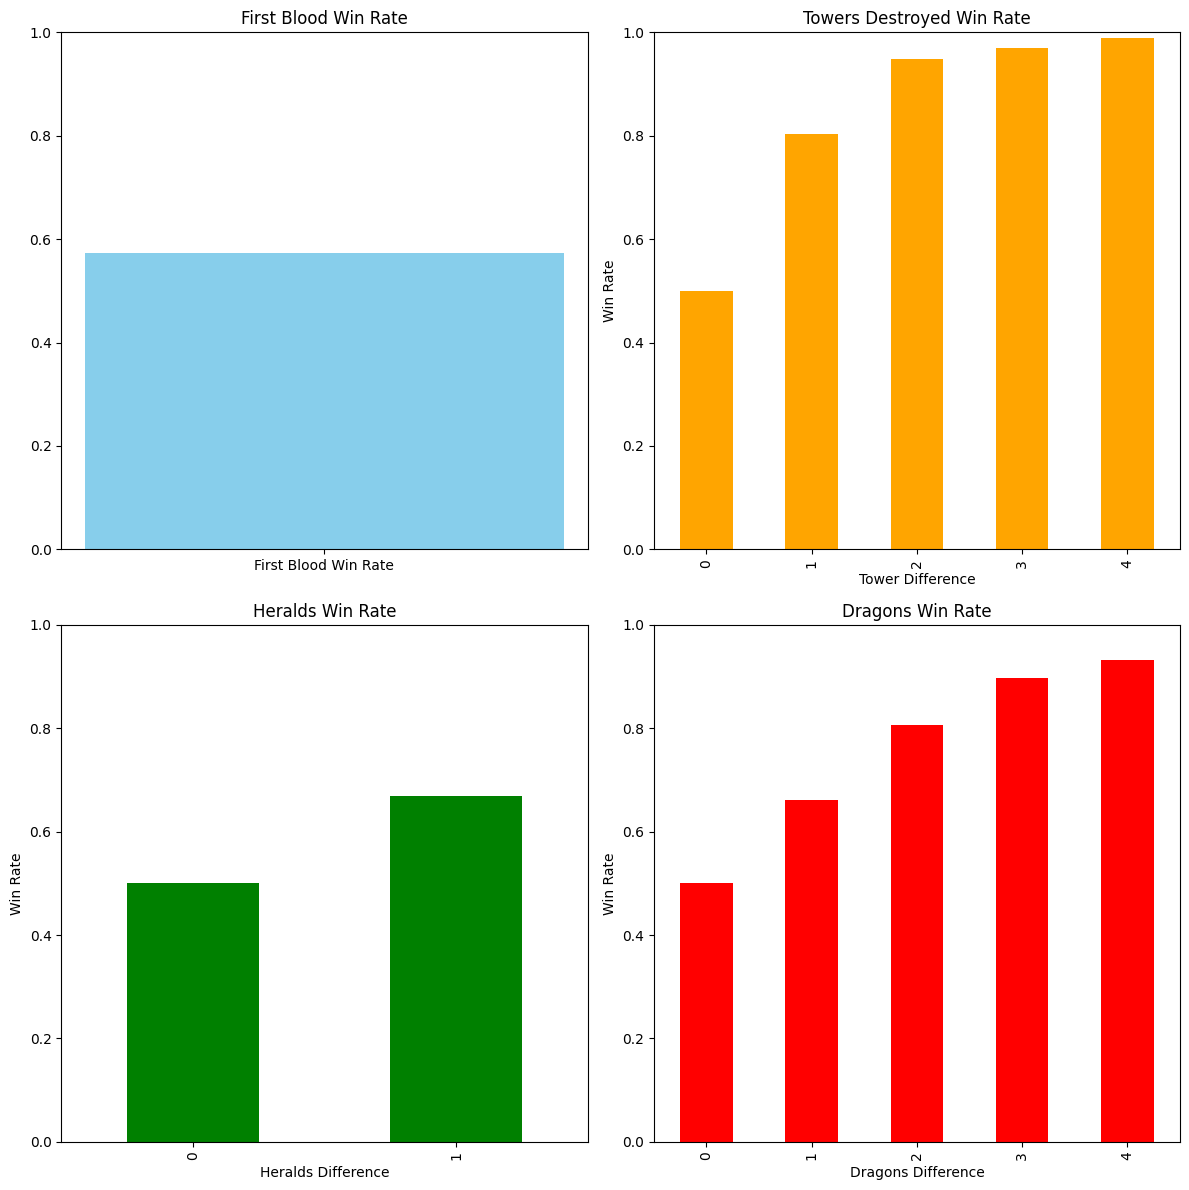

In [ ]:
total = challenger['gameId'].count()

first_blood_win_rate = challenger[((challenger['blueFirstBlood'] == 1) & (challenger['blueWins'] == 1)) | ((challenger['redFirstBlood'] == 1) & (challenger['blueWins'] == 0))].shape[0] / total

tower_diff_win_rate = []
for i in range(5):
    subset = challenger[(challenger['blueTowersDestroyed'] - challenger['redTowersDestroyed']).abs() == i]
    blue_wins = subset[(subset['blueTowersDestroyed'] > subset['redTowersDestroyed']) & (subset['blueWins'] == 1)].shape[0]
    red_wins = subset[(subset['blueTowersDestroyed'] < subset['redTowersDestroyed']) & (subset['blueWins'] == 0)].shape[0]
    total_wins = red_wins + blue_wins
    total_games = subset['blueWins'].count()
    if total_games != 0:
        win_rate = total_wins / total_games
    if win_rate == 0:
        win_rate = 0.5
    tower_diff_win_rate.append(win_rate)
tower_diff_win_rate_series = pd.Series(tower_diff_win_rate)

herald_diff_win_rate = []
for i in range(2):
    subset = challenger[(challenger['blueHeralds'] - challenger['redHeralds']).abs() == i]
    blue_wins = subset[(subset['blueHeralds'] > subset['redHeralds']) & (subset['blueWins'] == 1)].shape[0]
    red_wins = subset[(subset['blueHeralds'] < subset['redHeralds']) & (subset['blueWins'] == 0)].shape[0]
    total_wins = red_wins + blue_wins
    total_games = subset['blueWins'].count()
    if total_games != 0:
        win_rate = total_wins / total_games
    if win_rate == 0:
        win_rate = 0.5
    herald_diff_win_rate.append(win_rate)
herald_diff_win_rate_series = pd.Series(herald_diff_win_rate)

dragon_diff_win_rate = []
for i in range(5):
    subset = challenger[(challenger['blueDragons'] - challenger['redDragons']).abs() == i]
    blue_wins = subset[(subset['blueDragons'] > subset['redDragons']) & (subset['blueWins'] == 1)].shape[0]
    red_wins = subset[(subset['blueDragons'] < subset['redDragons']) & (subset['blueWins'] == 0)].shape[0]
    total_wins = red_wins + blue_wins
    total_games = subset['blueWins'].count()
    if total_games != 0:
        win_rate = total_wins / total_games
    if win_rate == 0:
        win_rate = 0.5
    dragon_diff_win_rate.append(win_rate)
dragon_diff_win_rate_series = pd.Series(dragon_diff_win_rate)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].bar(['First Blood Win Rate'], [first_blood_win_rate], color='skyblue')
axes[0, 0].set_title('First Blood Win Rate')
axes[0, 0].set_ylim([0, 1])

tower_diff_win_rate_series.plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Towers Destroyed Win Rate')
axes[0, 1].set_xlabel('Tower Difference')
axes[0, 1].set_ylabel('Win Rate')
axes[0, 1].set_ylim([0, 1])

herald_diff_win_rate_series.plot(kind='bar', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Heralds Win Rate')
axes[1, 0].set_xlabel('Heralds Difference')
axes[1, 0].set_ylabel('Win Rate')
axes[1, 0].set_ylim([0, 1])

dragon_diff_win_rate_series.plot(kind='bar', ax=axes[1, 1], color='red')
axes[1, 1].set_title('Dragons Win Rate')
axes[1, 1].set_xlabel('Dragons Difference')
axes[1, 1].set_ylabel('Win Rate')
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

Each chart above shows the impact of a feature on the game's final win rate in percentage. The reasons for choosing these four features are that they can be directly observed during the game, and their impact on the results can also be measured easily.

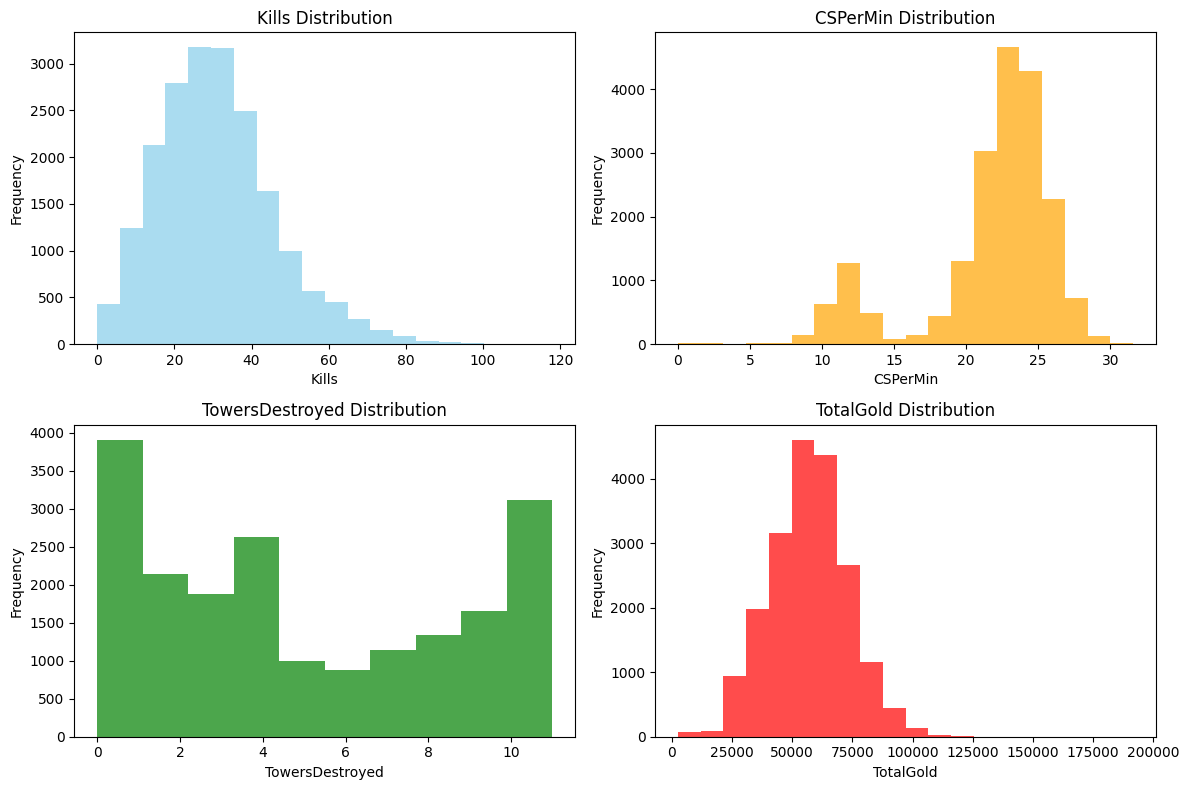

In [ ]:
kills = pd.concat([challenger['blueKills'], challenger['redKills']], ignore_index=True)
cs_per_min = pd.concat([challenger['blueCSPerMin'], challenger['redCSPerMin']], ignore_index=True)
wards_placed = pd.concat([challenger['blueTowersDestroyed'], challenger['redTowersDestroyed']], ignore_index=True)
total_gold = pd.concat([challenger['blueTotalGold'], challenger['redTotalGold']], ignore_index=True)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].hist(kills, bins=20, color='skyblue', alpha=0.7)
axs[0, 0].set_title('Kills Distribution')
axs[0, 0].set_xlabel('Kills')
axs[0, 0].set_ylabel('Frequency')

axs[0, 1].hist(cs_per_min, bins=20, color='orange', alpha=0.7)
axs[0, 1].set_title('CSPerMin Distribution')
axs[0, 1].set_xlabel('CSPerMin')
axs[0, 1].set_ylabel('Frequency')

axs[1, 0].hist(wards_placed, color='green', alpha=0.7)
axs[1, 0].set_title('TowersDestroyed Distribution')
axs[1, 0].set_xlabel('TowersDestroyed')
axs[1, 0].set_ylabel('Frequency')

axs[1, 1].hist(total_gold, bins=20, color='red', alpha=0.7)
axs[1, 1].set_title('TotalGold Distribution')
axs[1, 1].set_xlabel('TotalGold')
axs[1, 1].set_ylabel('Frequency')

plt.tight_layout()

plt.show()

Each chart above shows the distribution of a feature. The reasons for choosing these four features are that they are macro-level metrics that gives a high-level summarization about the game.

Below we want to drop some unrelated and duplicate colmns that are not contributing to the prediction. For example, `redFirstBlood`, `redKills` and `redDeaths` can be inferred from `blueFirstBlood`, `blueDeaths`, and `blueKills`. We also remove some derived features like `blueGoldPerMin` and `redGoldPerMin` because they are esssentially a scaled version of `blueTotalGold` and `redTotalGold`.

In [ ]:
challenger_cleaned = challenger.copy()
challenger_cleaned.drop(['gameId', 'blueEliteMonsters', 'blueTotalExperience', 'blueGoldPerMin',
                 'redFirstBlood', 'redKills', 'redDeaths', 'redEliteMonsters',
                 'redTotalGold', 'redTotalExperience', 'redGoldDiff',
                 'redExperienceDiff', 'redGoldPerMin'], axis=1, inplace=True)

print(challenger_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9843 entries, 0 to 9978
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   blueWins                      9843 non-null   int64  
 1   blueWardsPlaced               9843 non-null   int64  
 2   blueWardsDestroyed            9843 non-null   int64  
 3   blueFirstBlood                9843 non-null   int64  
 4   blueKills                     9843 non-null   int64  
 5   blueDeaths                    9843 non-null   int64  
 6   blueAssists                   9843 non-null   int64  
 7   blueDragons                   9843 non-null   int64  
 8   blueHeralds                   9843 non-null   int64  
 9   blueTowersDestroyed           9843 non-null   int64  
 10  blueTotalGold                 9843 non-null   int64  
 11  blueAvgLevel                  9843 non-null   float64
 12  blueTotalMinionsKilled        9843 non-null   int64  
 13  blu

Prepare Train/Test Split for model inference

In [ ]:
from sklearn.model_selection import train_test_split

y = challenger_cleaned['blueWins']
X = challenger_cleaned.drop(['blueWins', 'redWins'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=200)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7874, 26), (1969, 26), (7874,), (1969,))

Instantiate, Train, and Test Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

accuracy_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Visualize Model Performance Difference

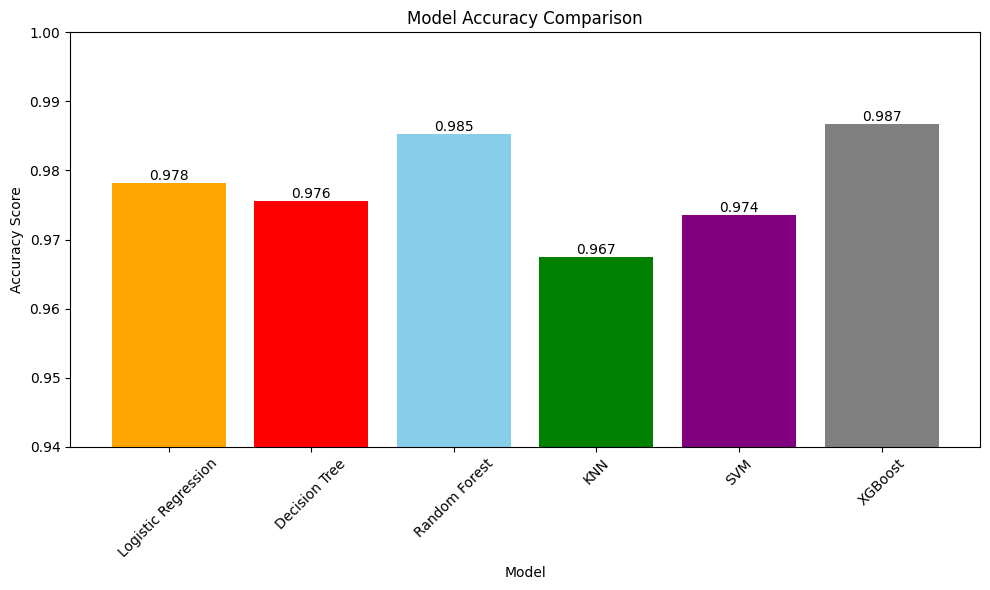

In [ ]:
plt.figure(figsize=(10, 6))
models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())

plt.bar(models, scores, color=["orange", "red", "skyblue", "green", "purple", "grey"])

for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.3f}', ha='center', va='bottom')

plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0.94, 1.0)
plt.tight_layout()

plt.show()

We observed that the XGBoost algorithm performed the best out of all the models with an amazing accuracy at 98.7% for predicting winning. The RandomForest stands out as the next best, with the all the rest perform well. Althogh the result far exceeded our expectation, it does seemed reasonable that XGBoost and RandomForest Performed the best out of all due to tree-based ML algorithm's strength on tabular data.

# Ethics & Privacy

### Biases and Privacy Concerns in Data

Our project uses a dataset of League of Legends Matches by Top 300 NA Players from Challenger Ranked Gameplays. This dataset was webscraped by us using Riot API for its relevance to our research question but comes with inherent biases and privacy considerations:

- **Terms of Service (TOS) Adherence:** We ensured that our data collection and usage comply with the game's Terms of Service. Our dataset consists of publicly available data, omitting any information players have chosen to keep private. This adherence respects player privacy but also means our dataset may not fully represent all player experiences.
  
- **Bias Toward High Elo Players:** By focusing on Challenger rank games, our analysis inherently excludes the broader player base, particularly those in lower or higher ranks. This exclusion could limit the generalizability of our findings, as player strategies, game dynamics, and outcomes can vary significantly across different skill levels.

- **Temporal Bias:** Given the dataset only contains relevant information from matches played in Feburary 2024, which should be recent enough to generalize to other recent matches. However, it could still possibly not accurately reflect the most current gameplay strategies, meta, or player behaviors due to the game's evolving nature. This temporal bias can affect the applicability of our findings to the current state of the game.

### Better Enforcing Ethics

To perform more ethical data analysis, our group plans to employ the following approaches:
  
- **Most Recent Data Sources:** As we mentioned above, we put effort into obtaining dataset that cover a higher rank and more recent gameplay. This approach could make sure that our analysis is not out-dated and in large free from temporal bias.

- **Transparent Reporting:** Clearly communicate the limitations of our data and analysis in our report and presentations. This transparency includes discussing the rank specificity of our dataset, the temporal limitations, and the potential biases these factors introduce.

### Ethical Considerations and Equitable Impact

- **Privacy and Data Use:** We ensured all data used in our project is anonymized and does not allow for the identification of individual players by only analyzing team-level metrics. This also makes sense because each match has different players, and it's necessary to prevent the model from making preditions based on specific users, which would render the analysis obsolete given that the players vary from match to match. We will also respect privacy choices and only use data that has been made publicly available under the game’s terms of service.

<!-- This text in this chapter were partly generated by GPT-4 from the prompt "expand my response on this question:Data that is used in games to make apps or reports have been used before. The main thing they typically do to avoid privacy issues is to follow Terms of Service(TOS). That is if a player chooses to hide their name or stats, then we can’t use their data. So this makes it that our data isn’t collected from every league player, but a good majority is being used. Also because a specific rank is being used in the data, we can’t extrapolate that data to other league players and have to keep our analysis to players in diamond. This dataset was also last updated 4 years ago. League is a game with constant updates so we can’t take findings about what we know from 4 years in the past to the current state of the game. But we can address it by mentioning the year of the data or hopefully find a more current dataset while working on the project." -->

# Discusison and Conclusion

In conclusion, we found that there were multiple metrics that had significant impact on the win rate of any given team. In League of Legends, game performance metrics such as kills, deaths, gold earned, and experience gained, is often considered crucial in setting the stage for the rest of the match. We were able to see this in our data in which certain features of the game would have a positive and negative direct correlation with the win rate of a team.
\
\
We are able to see in the Correlation Matrix of Blue Team Features what specific metrics have the most and least correlation to win rate in both the positive and negative directions. Looking at the Correlation Coefficient with Blue Wins, we can see that gold and experience difference has the highest correlation to win rate. We can also see that deaths has the highest negative correlation to win rate which makes sense because giving up kills gives the enemy team gold and experience. We can also look at the graph below that one and see that there are multiple observable features in the game that can contribute to an increase in win rate such as a difference in towers destroyed which grants gold across the whole team. There is also a higher win rate for the team with the most dragons which increases with the increasing difference in dragons slain. Not only does slaying the dragon grant gold and some experience, but it also provides a small buff to the entire team which can impact the chances of winning the game. There is even a small increase in win rate for whichever team aqcuires the rift herald which is an early game objective that can be used to destroy towers quickly. This is likely because the team that gets herald is able to destroy towers quickly and get gold for their entire team which contributes to one of the highest correlating factors, gold difference. Both dragons and heralds would fall under blueEliteMonsters which is the 4th highest correlating coefficient.
\
\
We were able to create six models that performed very well when it came to predicting the outcome of the game with the given data. We observed that the XGBoost algorithm performed the best out of all the models with an amazing accuracy at 98.7% for predicting winning. The RandomForest stands out as the next best with 98.5% accuracy. Our least accurate model was the K-nearest neighbors (KNN) classifier still had an accuracy of 96.7%. Notice that Decision Tree model performed quite well with 97.6% accuracy. Since XGBoost takes considerably more time to train than a simple decision tree classifier, if one want to use a smaller model that trains faster and with good performance, the decision tree model could still be a valid choice.
\
\
Althogh the accuracy far exceeded our expectation, the fact that XGBoost and RandomForest turned out to be the best two out of all models indeed matched our initial expectation, as tree-based ML algorithms are often seen to achieve strong performance on tabular data.
\
\
Imagine looking at the 40 metrics and predict the outcome for 99 games correct out of 100 games - this is not feasible for human. It is in the process of implementing our project that we started to appreciate the mighty power of Machine Learning.


<!-- Every model showed that the gold difference was the biggest indicator as to which teams win with towers destroyed and the experience difference also being important features in determining which team wins. This is in line with the correlation matrix mentioned earlier.  The two best models weighed these features differently. The XGBoost gave far more weight to the gold difference than the other two features while the random forest classifier gave them similar weights with the gold difference still being the most important feature. -->


# Team Contributions

In this project, Shang Zhou took on the major role of creating the dataset and writing the majority of the code in the notebook. Yunfan Long contributed the most to visualization code for Check Point #1 and #2, annotating the code, and parsing the dataset. Yuxi Liu focused primarily on the writing aspects, including the abstract, background, and ethics sections. Nathan Truong and Nithilan Muruganandham worked together on the project proposal and the project review.